# 🏥 AI Research Paper Literature Analyzer
### Healthcare Domain — Full NLP Pipeline
> **Dataset**: ArXiv q-bio (Healthcare-labeled, 26,125 rows)  
> **Pipeline**: Keyword Extraction → Topic Modeling → Trend Analysis → Citation Patterns → Research Gap Detection → Final Report

---

## 📦 STEP 1 — Install Dependencies

In [67]:
%%capture
!pip install keybert sentence-transformers
!pip install yake
!pip install rake-nltk
!pip install bertopic
!pip install plotly kaleido
!pip install wordcloud
!pip install scikit-learn
!pip install umap-learn
!pip install hdbscan
!pip install networkx
!pip install spacy
!python -m spacy download en_core_web_sm

## 📚 STEP 2 — Import Libraries

In [68]:
import pandas as pd
import numpy as np
import re
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import networkx as nx
from collections import Counter, defaultdict
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
import spacy
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

warnings.filterwarnings('ignore')

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

nlp = spacy.load('en_core_web_sm')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-whitegrid')

print('✅ All libraries loaded!')

✅ All libraries loaded!


In [69]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [70]:
url = "/content/drive/MyDrive/final_dataset.csv"
df = pd.read_csv(url)

## 📂 STEP 3 — Load Healthcare Dataset

In [71]:
# Load your healthcare-labeled CSV

# Keep only healthcare-labeled rows (label == 1)
if 'healthcare_label' in df.columns:
    df = df[df['healthcare_label'] == 1].reset_index(drop=True)
    print(f'✅ Healthcare papers loaded: {len(df):,} rows')
else:
    print('⚠️  healthcare_label column not found — using all rows')

# Standardise column names (handle variations)
df.columns = df.columns.str.strip().str.lower().str.replace('-', '_')
keybert_sample = df.sample(min(500, len(df)), random_state=42)
# Ensure year is numeric
if 'year' in df.columns:
    df['year'] = pd.to_numeric(df['year'], errors='coerce')

print(df.head(3))
print(f'\nColumns: {list(df.columns)}')
print(f'Year range: {df["year"].min()} – {df["year"].max()}')

✅ Healthcare papers loaded: 26,125 rows
         id                                              title  \
0   704.139      Velocity oscillations in actin-based motility   
1  704.2547  Inferring DNA sequences from mechanical unzipp...   
2  704.3226     Delay estimation in a two-node acyclic network   

                                            abstract  \
0    We present a simple and generic theoretical ...   
1    The complementary strands of DNA molecules c...   
2    Linear measures such as cross-correlation ha...   

                                             authors  \
0            Azam Gholami, Martin Falcke, Erwin Frey   
1  Valentina Baldazzi (LPS), Serena Bradde (LPS),...   
2                            Radhakrishnan Nagarajan   

                                      authors_parsed  \
0  [['Gholami', 'Azam', ''], ['Falcke', 'Martin',...   
1  [['Baldazzi', 'Valentina', '', 'LPS'], ['Bradd...   
2               [['Nagarajan', 'Radhakrishnan', '']]   

                    

In [72]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## 🧹 STEP 4 — Text Preprocessing

In [73]:
STOP_WORDS = set(stopwords.words('english'))
DOMAIN_STOP = {
    'paper', 'study', 'result', 'results', 'method', 'methods',
    'approach', 'propose', 'proposed', 'show', 'using', 'based',
    'model', 'data', 'analysis', 'present', 'also', 'two', 'one',
    'new', 'work', 'use', 'used', 'et', 'al', 'arxiv', 'fig',
    'table', 'section', 'however', 'thus', 'therefore'
}
ALL_STOPS = STOP_WORDS | DOMAIN_STOP
lemmatizer = WordNetLemmatizer()

def preprocess(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'\$.*?\$', '', text)          # remove LaTeX math
    text = re.sub(r'\\[a-zA-Z]+', '', text)       # remove LaTeX commands
    text = re.sub(r'[^a-zA-Z\s\-]', ' ', text)   # keep letters, hyphens
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [
        lemmatizer.lemmatize(t) for t in tokens
        if t not in ALL_STOPS and len(t) > 2
    ]
    return ' '.join(tokens)

print('Preprocessing abstracts...')
df['abstract_clean'] = df['abstract'].apply(preprocess)
df['title_clean']    = df['title'].apply(preprocess)
df['combined_text']  = df['title_clean'] + ' ' + df['abstract_clean']

# Remove rows with very short cleaned text
df = df[df['abstract_clean'].str.len() > 50].reset_index(drop=True)
print(f'✅ After preprocessing: {len(df):,} papers')

Preprocessing abstracts...
✅ After preprocessing: 26,119 papers


## 🔑 STEP 5 — Keyword Extraction (TF-IDF + YAKE + KeyBERT)

In [74]:
# ── 5A: TF-IDF Global Keywords ──────────────────────────────────
print('Running TF-IDF keyword extraction...')

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 3),
    min_df=5,
    max_df=0.85
)
tfidf_matrix = tfidf.fit_transform(df['combined_text'])
feature_names = tfidf.get_feature_names_out()

# Mean TF-IDF score across all documents
mean_tfidf = np.array(tfidf_matrix.mean(axis=0)).flatten()
tfidf_scores = pd.Series(mean_tfidf, index=feature_names).sort_values(ascending=False)

top_tfidf_keywords = tfidf_scores.head(50)
print(f'✅ Top TF-IDF keywords extracted')
print(top_tfidf_keywords.head(20))

Running TF-IDF keyword extraction...
✅ Top TF-IDF keywords extracted
network        0.027137
cell           0.023467
protein        0.021213
model          0.020879
system         0.018154
learning       0.017697
dynamic        0.016795
brain          0.016288
time           0.015507
neural         0.014549
population     0.014393
structure      0.014142
state          0.013118
gene           0.012647
disease        0.012045
interaction    0.011852
process        0.011711
information    0.011643
human          0.011403
sequence       0.011368
dtype: float64


In [75]:
# ── 5B: YAKE Keyword Extraction ───────────
import yake

yake_extractor = yake.KeywordExtractor(
    lan='en',
    n=3,          # max n-gram
    dedupLim=0.7,
    top=10
)

print('Running YAKE...')
sample_df = df.sample(min(26000, len(df)), random_state=42)

all_yake_keywords = []
for abstract in sample_df['abstract'].fillna(''):
    try:
        kws = yake_extractor.extract_keywords(abstract)
        all_yake_keywords.extend([kw[0].lower() for kw in kws])
    except:
        pass

yake_freq = Counter(all_yake_keywords)
top_yake = pd.Series(dict(yake_freq.most_common(50)))
print(f'✅ YAKE: {len(yake_freq):,} unique keywords extracted')
print(top_yake.head(20))

Running YAKE...
✅ YAKE: 178,454 unique keywords extracted
model                         697
data                          472
neural networks               370
brain                         352
models                        350
machine learning              350
protein                       333
drug discovery                305
cell                          290
dna                           283
deep learning                 278
networks                      267
learning                      242
network                       240
neural                        220
cells                         200
species                       197
magnetic resonance imaging    184
artificial intelligence       182
gene expression               180
dtype: int64


In [76]:
# ── 5C: KeyBERT (semantic keyword extraction) ───────────────────
from keybert import KeyBERT

print('Loading KeyBERT model (this may take a moment)...')
kw_model = KeyBERT(model='all-MiniLM-L6-v2')

print('Running KeyBERT')
all_keybert_kws = []

for idx, row in keybert_sample.iterrows():
    text = str(row['abstract'])[:1000]  # cap length
    try:
        kws = kw_model.extract_keywords(
            text,
            keyphrase_ngram_range=(1, 2),
            stop_words='english',
            top_n=8,
            use_mmr=True,
            diversity=0.5
        )
        all_keybert_kws.extend([kw[0].lower() for kw in kws])
    except:
        pass

keybert_freq = Counter(all_keybert_kws)
top_keybert = pd.Series(dict(keybert_freq.most_common(50)))
print(f'✅ KeyBERT: {len(keybert_freq):,} unique keywords')
print(top_keybert.head(20))

Loading KeyBERT model (this may take a moment)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Running KeyBERT
✅ KeyBERT: 3,832 unique keywords
deep learning              9
covid 19                   9
numerical simulations      5
time series                5
machine learning           5
alzheimer disease          5
regulatory networks        4
structure prediction       4
molecular dynamics         4
data driven                4
language models            4
population dynamics        4
foundation models          4
functional connectivity    3
gaussian process           3
transfer learning          3
gene expression            3
epidemic model             3
19 pandemic                3
protein structures         3
dtype: int64


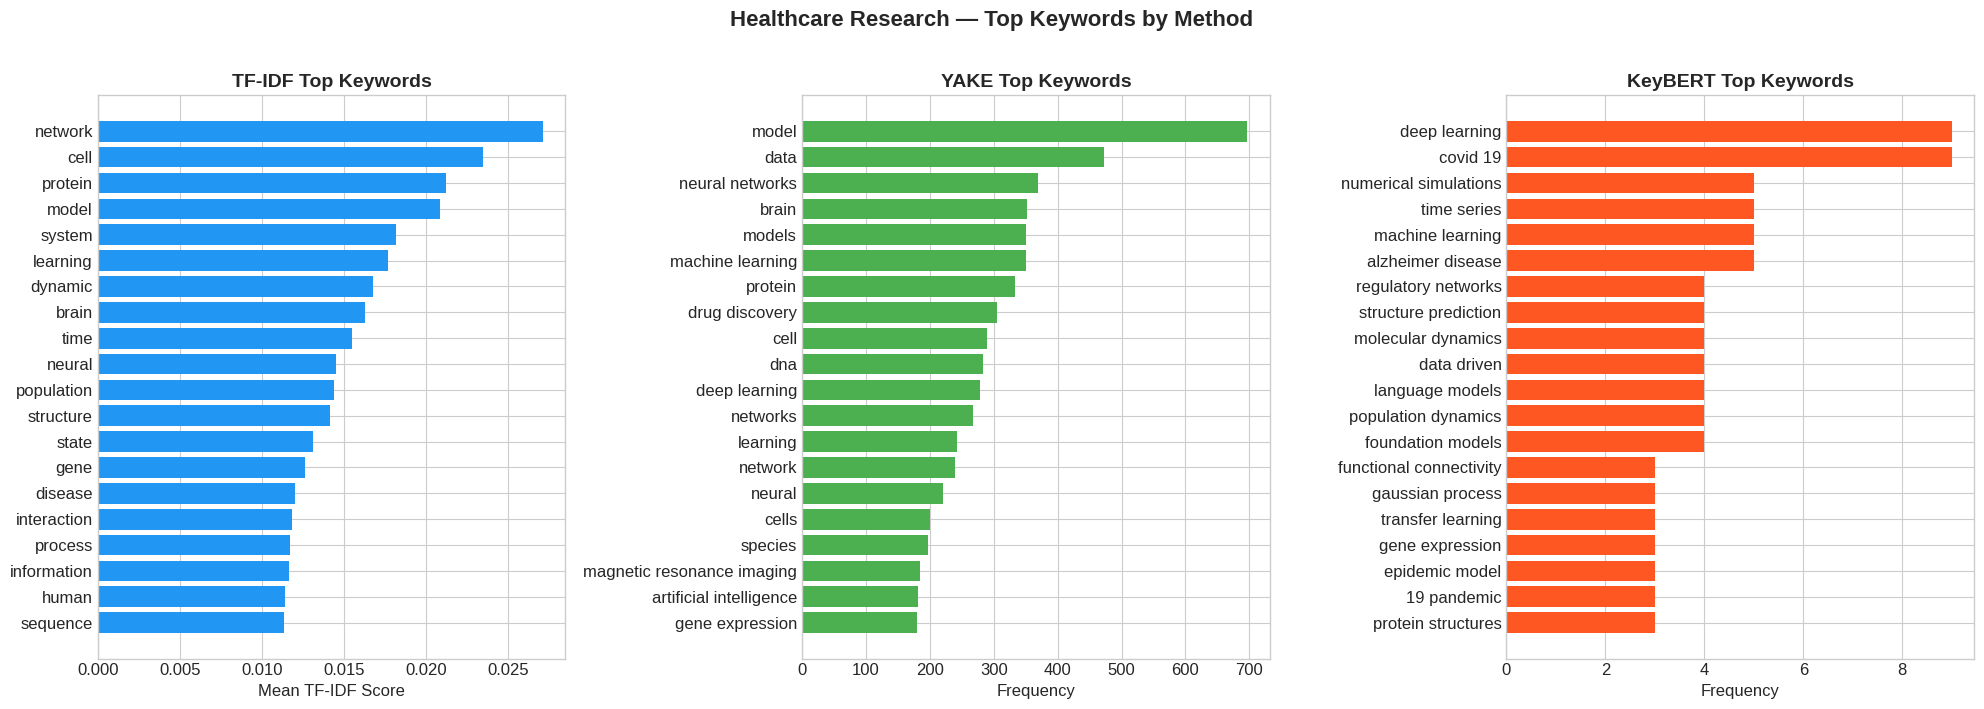

✅ Keyword comparison chart saved


In [77]:
# ── 5D: Visualize Top Keywords ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# TF-IDF
top_n = 20
axes[0].barh(top_tfidf_keywords.head(top_n).index[::-1],
             top_tfidf_keywords.head(top_n).values[::-1],
             color='#2196F3')
axes[0].set_title('TF-IDF Top Keywords', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Mean TF-IDF Score')

# YAKE
axes[1].barh(top_yake.head(top_n).index[::-1],
             top_yake.head(top_n).values[::-1],
             color='#4CAF50')
axes[1].set_title('YAKE Top Keywords', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency')

# KeyBERT
axes[2].barh(top_keybert.head(top_n).index[::-1],
             top_keybert.head(top_n).values[::-1],
             color='#FF5722')
axes[2].set_title('KeyBERT Top Keywords', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Frequency')

plt.suptitle('Healthcare Research — Top Keywords by Method', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('keywords_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Keyword comparison chart saved')

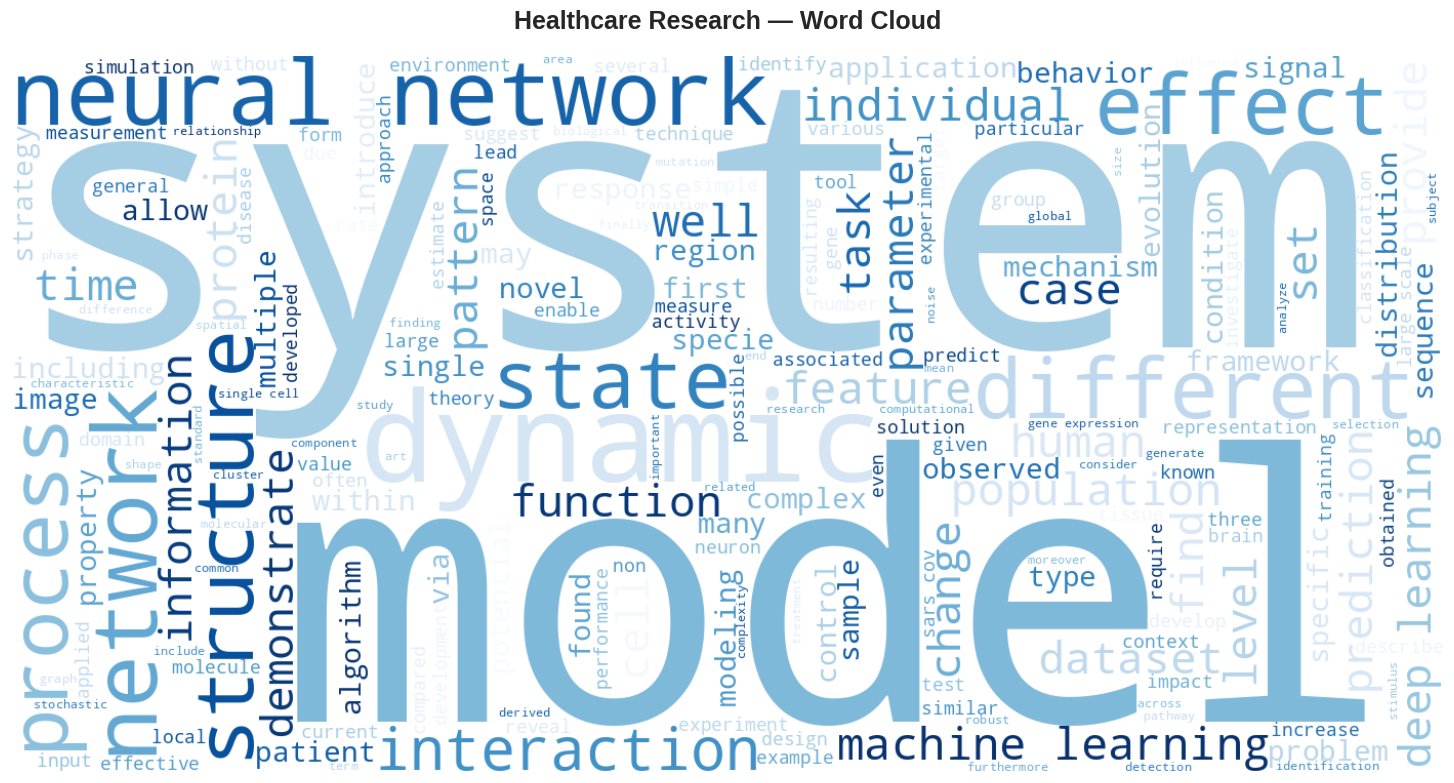

✅ Word cloud saved


In [78]:
# ── 5E: Word Cloud ───────────────────────────────────────────────
all_text_corpus = ' '.join(df['combined_text'].tolist())

wc = WordCloud(
    width=1400,
    height=700,
    background_color='white',
    colormap='Blues',
    max_words=200,
    collocations=True,
    prefer_horizontal=0.8
).generate(all_text_corpus)

plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Healthcare Research — Word Cloud', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('wordcloud_healthcare.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Word cloud saved')

## 🗂️ STEP 6 — Topic Modeling (LDA + BERTopic)

In [79]:
# ── 6A: LDA Topic Modeling ───────────────────────────────────────
print('Running LDA topic modeling...')

N_TOPICS = 10

count_vec = CountVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.90
)
count_matrix = count_vec.fit_transform(df['combined_text'])
count_feature_names = count_vec.get_feature_names_out()

lda_model = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=20,
    learning_method='online',
    batch_size=512
)
lda_output = lda_model.fit_transform(count_matrix)

df['dominant_topic_lda'] = lda_output.argmax(axis=1)
df['topic_confidence']   = lda_output.max(axis=1)

# Extract top words per topic
def get_topic_words(model, feature_names, n_top=12):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top - 1:-1]]
        topics[f'Topic {topic_idx}'] = top_words
    return topics

lda_topics = get_topic_words(lda_model, count_feature_names)

print('\n=== LDA Topics ===')
for topic, words in lda_topics.items():
    print(f'{topic}: {", ".join(words)}')

Running LDA topic modeling...

=== LDA Topics ===
Topic 0: gene, dna, genome, sequence, expression, tree, rna, algorithm, genetic, sample, single, genomic
Topic 1: learning, model, prediction, based, deep, performance, machine, task, drug, feature, image, framework
Topic 2: protein, structure, network, interaction, energy, molecular, sequence, property, quantum, biological, function, structural
Topic 3: disease, covid, infection, epidemic, virus, transmission, spread, cov, control, number, sars, case
Topic 4: neuron, signal, response, time, system, activity, input, neural, neuronal, decision, spike, control
Topic 5: network, brain, neural, human, functional, information, neural network, visual, connectivity, task, cognitive, eeg
Topic 6: cell, binding, protein, membrane, mechanism, tissue, cellular, receptor, drug, concentration, ligand, surface
Topic 7: population, specie, evolution, individual, evolutionary, interaction, effect, environment, community, environmental, strategy, select

In [80]:
# ── 6B: Assign meaningful labels to LDA topics ──────────────────
# After reviewing the topic words above, assign human-readable labels.
# Edit these based on what the LDA output shows for YOUR data.

TOPIC_LABELS = {
    0: 'gene, dna, genome, sequence, expression, tree, rna, algorithm, genetic, sample, single, genomic',
    1: 'learning, model, prediction, based, deep, performance, machine, task, drug, feature, image, framework',
    2: 'protein, structure, network, interaction, energy, molecular, sequence, property, quantum, biological, function, structural',
    3: 'disease, covid, infection, epidemic, virus, transmission, spread, cov, control, number, sars, case',
    4: 'neuron, signal, response, time, system, activity, input, neural, neuronal, decision, spike, control',
    5: 'network, brain, neural, human, functional, information, neural network, visual, connectivity, task, cognitive, eeg',
    6: 'cell, binding, protein, membrane, mechanism, tissue, cellular, receptor, drug, concentration, ligand, surface',
    7: 'population, specie, evolution, individual, evolutionary, interaction, effect, environment, community, environmental, strategy, selection',
    8: 'dynamic, system, model, time, parameter, equation, state, process, population, stochastic, distribution, simulation',
    9: 'cancer, patient, disease, clinical, treatment, tumor, risk, imaging, diagnosis, study, blood, detection'
}

df['topic_label'] = df['dominant_topic_lda'].map(TOPIC_LABELS)
topic_dist = df['topic_label'].value_counts()

fig = px.bar(
    x=topic_dist.values,
    y=topic_dist.index,
    orientation='h',
    title='Distribution of Healthcare Research Topics (LDA)',
    labels={'x': 'Number of Papers', 'y': 'Topic'},
    color=topic_dist.values,
    color_continuous_scale='Blues'
)
fig.update_layout(height=500, showlegend=False)
fig.show()
fig.write_html('lda_topic_distribution.html')
print('✅ LDA topic distribution saved')

✅ LDA topic distribution saved


In [81]:
# ── 6C: BERTopic ────────────────────────────────────────────────
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

print('Running BERTopic (this may take several minutes on GPU)...')

# Use a subset for speed — increase if you have time/GPU
BERTOPIC_SAMPLE = min(26000, len(df))
bert_df = df.sample(BERTOPIC_SAMPLE, random_state=42).reset_index(drop=True)
docs = bert_df['abstract'].fillna('').tolist()

embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

topic_model = BERTopic(
    embedding_model=embedding_model,
    nr_topics='auto',
    min_topic_size=20,
    verbose=True
)
topics, probs = topic_model.fit_transform(docs)
bert_df['bertopic'] = topics

print(f'✅ BERTopic found {topic_model.get_topic_info().shape[0] - 1} topics')
print(topic_model.get_topic_info().head(15))

Running BERTopic (this may take several minutes on GPU)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-05-08 06:50:46,270 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/813 [00:00<?, ?it/s]

2026-05-08 06:51:59,405 - BERTopic - Embedding - Completed ✓
2026-05-08 06:51:59,406 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-08 06:52:20,592 - BERTopic - Dimensionality - Completed ✓
2026-05-08 06:52:20,593 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-08 06:52:26,170 - BERTopic - Cluster - Completed ✓
2026-05-08 06:52:26,171 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-08 06:52:29,252 - BERTopic - Representation - Completed ✓
2026-05-08 06:52:29,256 - BERTopic - Topic reduction - Reducing number of topics
2026-05-08 06:52:29,313 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-08 06:52:34,171 - BERTopic - Representation - Completed ✓
2026-05-08 06:52:34,178 - BERTopic - Topic reduction - Reduced number of topics from 153 to 102


✅ BERTopic found 101 topics
    Topic  Count                                     Name  \
0      -1  11504                         -1_the_of_and_to   
1       0   2146        0_protein_molecular_drug_proteins   
2       1    808             1_covid_19_epidemic_pandemic   
3       2    792         2_neural_neurons_visual_networks   
4       3    729            3_species_population_the_prey   
5       4    667     4_brain_functional_connectivity_fmri   
6       5    535       5_reaction_chemical_the_stochastic   
7       6    521                 6_gene_cancer_genes_cell   
8       7    512              7_cell_cells_mechanical_the   
9       8    482          8_segmentation_images_image_mri   
10      9    443                  9_eeg_bci_signals_brain   
11     10    437  10_phylogenetic_tree_trees_evolutionary   
12     11    277                     11_cov_sars_covid_19   
13     12    263         12_cooperation_game_social_games   
14     13    254             13_reads_dna_sequencing_read

In [82]:
# BERTopic visualizations
try:
    fig_topics = topic_model.visualize_topics()
    fig_topics.write_html('bertopic_intertopic_distance.html')
    fig_topics.show()

    fig_bar = topic_model.visualize_barchart(top_n_topics=10)
    fig_bar.write_html('bertopic_barchart.html')
    fig_bar.show()
    print('✅ BERTopic visualizations saved')
except Exception as e:
    print(f'BERTopic visualization skipped: {e}')

✅ BERTopic visualizations saved


## 📈 STEP 7 — Publication Trend Analysis

In [83]:
# ── 7A: Overall Publication Trends ──────────────────────────────
year_counts = df.groupby('year').size().reset_index(name='count')
# year_counts = year_counts[year_counts['year'] >= 2015]  # filter out early erroneous years

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Publications Per Year', 'Cumulative Publications'])

fig.add_trace(go.Bar(
    x=year_counts['year'], y=year_counts['count'],
    name='Annual', marker_color='#1976D2'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=year_counts['year'],
    y=year_counts['count'].cumsum(),
    mode='lines+markers',
    name='Cumulative',
    line=dict(color='#E53935', width=2)
), row=1, col=2)

fig.update_layout(
    title='Healthcare Research Publications — Temporal Trends',
    height=450,
    showlegend=False
)
fig.show()
fig.write_html('publication_trends.html')
print('✅ Publication trend chart saved')

✅ Publication trend chart saved


In [84]:
# ── 7B: Topic Trends Over Time ───────────────────────────────────
topic_year = (
    df[df['year'] >= 2005]
    .groupby(['year', 'topic_label'])
    .size()
    .reset_index(name='count')
)

fig = px.line(
    topic_year,
    x='year',
    y='count',
    color='topic_label',
    title='Healthcare Research Topics — Publication Trends Over Time',
    labels={'count': 'Papers Published', 'year': 'Year', 'topic_label': 'Topic'},
    markers=True
)
fig.update_layout(height=550, legend=dict(orientation='v', x=1.01))
fig.show()
fig.write_html('topic_trends_over_time.html')
print('✅ Topic trend chart saved')

✅ Topic trend chart saved


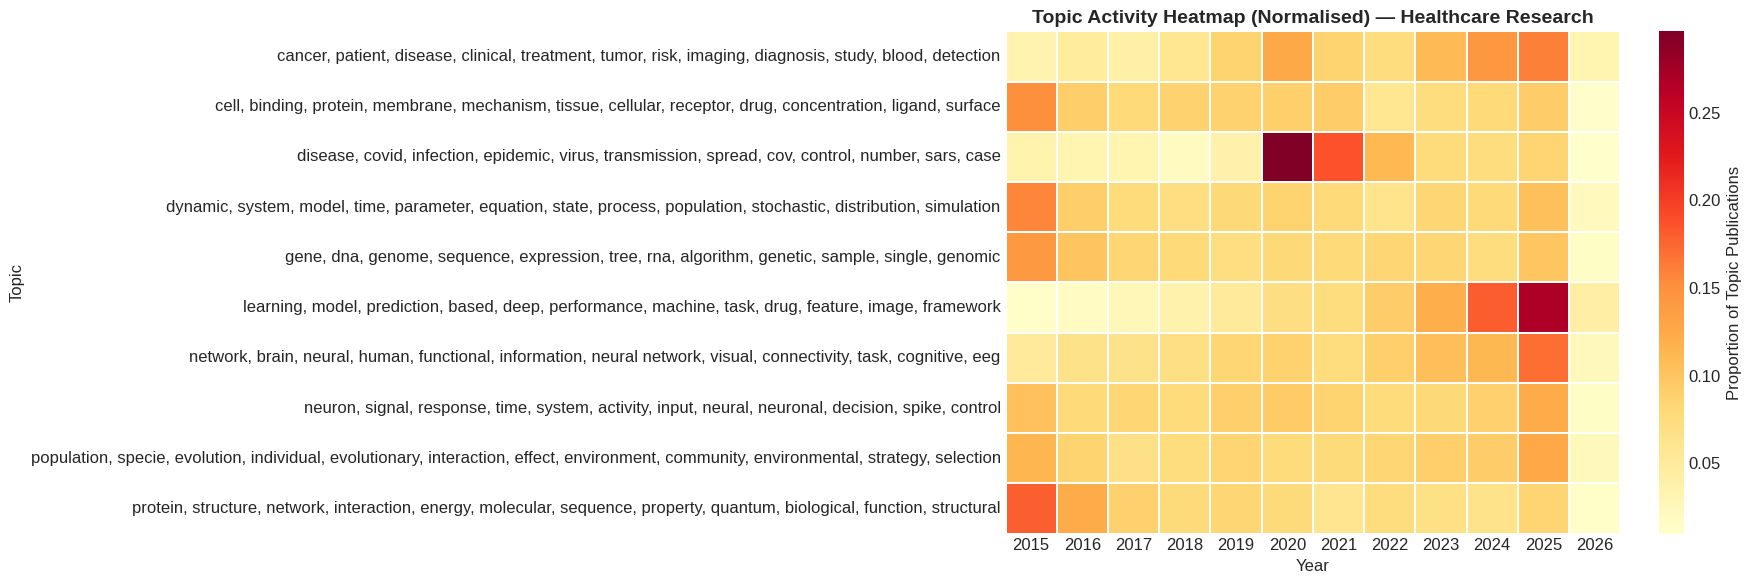

✅ Topic heatmap saved


In [85]:
# ── 7C: Topic Heatmap (Year × Topic) ────────────────────────────
topic_year_pivot = topic_year.pivot_table(
    index='topic_label',
    columns='year',
    values='count',
    fill_value=0
)
# Normalise each topic row so fast-growing topics don't overshadow smaller ones
topic_year_norm = topic_year_pivot.div(topic_year_pivot.sum(axis=1), axis=0)

plt.figure(figsize=(18, 6))
sns.heatmap(
    topic_year_norm,
    annot=False,
    cmap='YlOrRd',
    linewidths=0.3,
    cbar_kws={'label': 'Proportion of Topic Publications'}
)
plt.title('Topic Activity Heatmap (Normalised) — Healthcare Research', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Topic')
plt.tight_layout()
plt.savefig('topic_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Topic heatmap saved')

## 🔗 STEP 8 — Keyword Co-occurrence Network

In [86]:
# ── 8A: Build Co-occurrence Matrix ───────────────────────────────
print('Building keyword co-occurrence network...')

TOP_K_KEYWORDS = 60  # use top K TF-IDF keywords for the network
top_keywords = list(top_tfidf_keywords.head(TOP_K_KEYWORDS).index)

# Filter the TF-IDF matrix to top keywords only
top_kw_indices = [np.where(feature_names == kw)[0][0]
                  for kw in top_keywords
                  if kw in feature_names]
top_keywords   = [feature_names[i] for i in top_kw_indices]
tfidf_top      = tfidf_matrix[:, top_kw_indices]

# Binarise: does this paper contain this keyword?
binary_matrix = (tfidf_top > 0).astype(int)
cooccurrence  = (binary_matrix.T @ binary_matrix).toarray()
np.fill_diagonal(cooccurrence, 0)  # remove self-loops

print(f'✅ Co-occurrence matrix: {cooccurrence.shape}')

Building keyword co-occurrence network...
✅ Co-occurrence matrix: (50, 50)


Network: 46 nodes, 305 edges


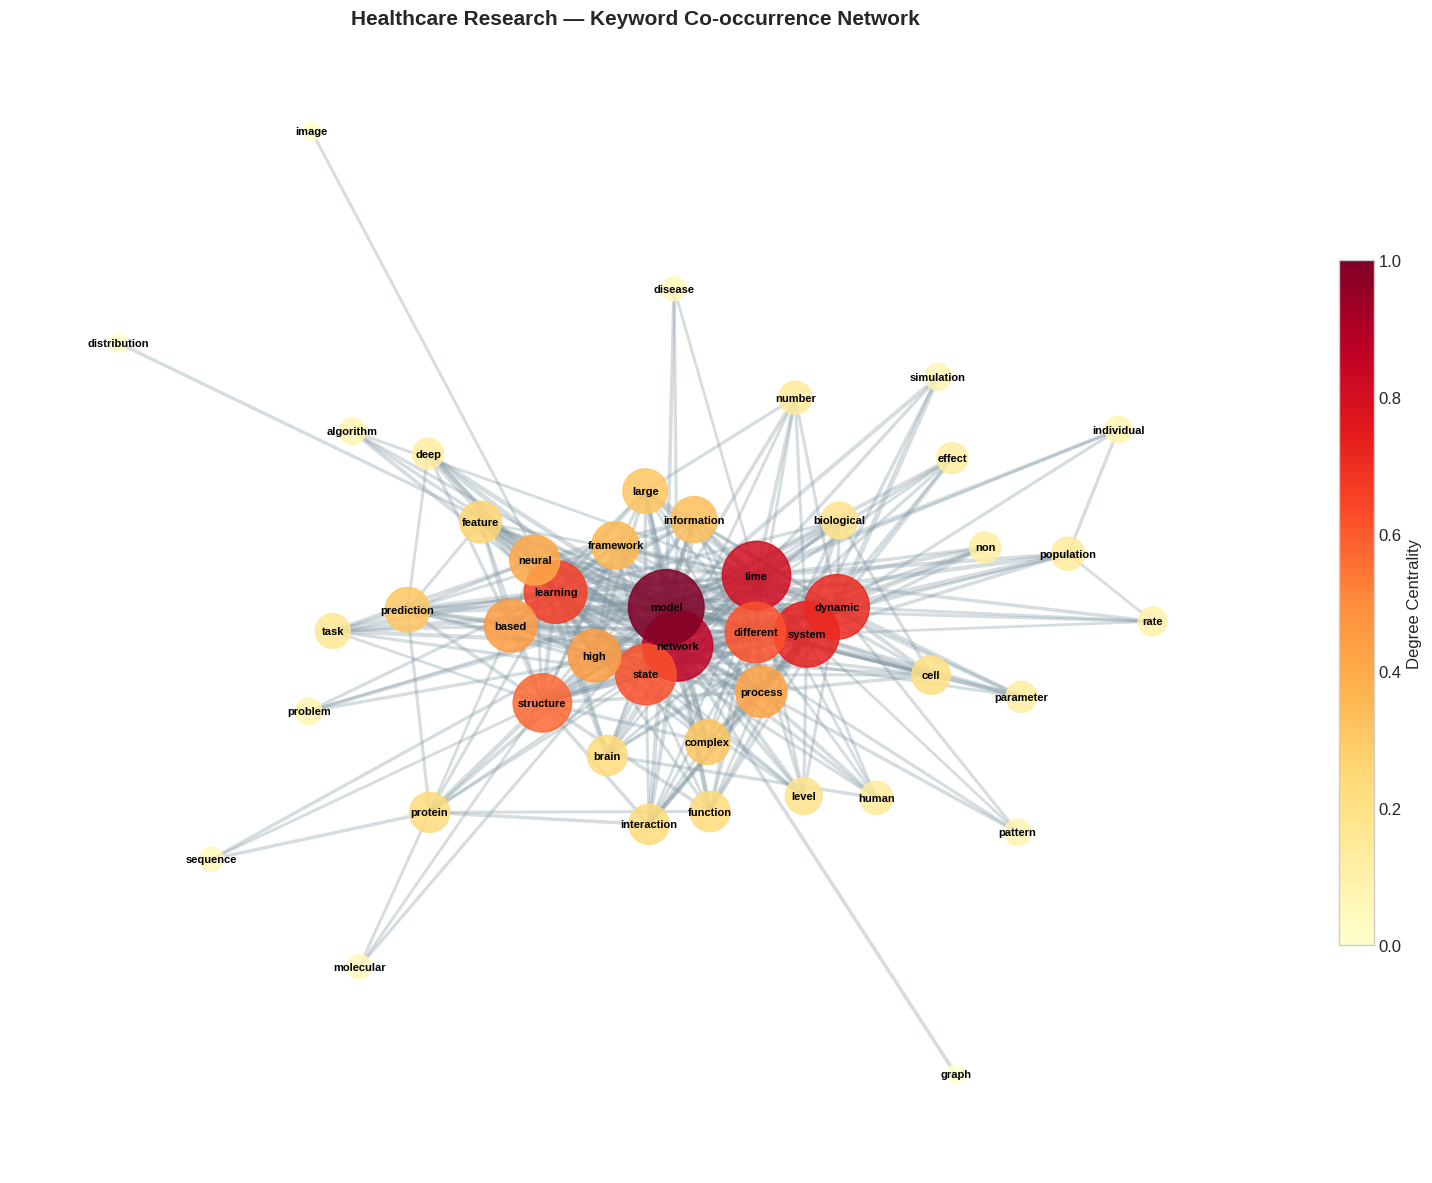

✅ Co-occurrence network saved


In [87]:
# ── 8B: Visualise Co-occurrence Network ──────────────────────────
EDGE_THRESHOLD = np.percentile(cooccurrence[cooccurrence > 0], 75)  # keep top 25% edges

G = nx.Graph()
G.add_nodes_from(top_keywords)

for i, kw1 in enumerate(top_keywords):
    for j, kw2 in enumerate(top_keywords):
        if i < j and cooccurrence[i, j] > EDGE_THRESHOLD:
            G.add_edge(kw1, kw2, weight=int(cooccurrence[i, j]))

# Remove isolated nodes
G.remove_nodes_from(list(nx.isolates(G)))

print(f'Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')

# Layout
pos = nx.spring_layout(G, seed=42, k=2.5)

degree_centrality = nx.degree_centrality(G)
node_sizes  = [degree_centrality[n] * 3000 + 100 for n in G.nodes()]
edge_widths = [G[u][v]['weight'] / EDGE_THRESHOLD * 2 for u, v in G.edges()]

plt.figure(figsize=(16, 12))
nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                       node_color=[degree_centrality[n] for n in G.nodes()],
                       cmap=plt.cm.YlOrRd, alpha=0.85)
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.3, edge_color='#78909C')
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')
plt.title('Healthcare Research — Keyword Co-occurrence Network', fontsize=15, fontweight='bold')
plt.axis('off')
sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd,
                            norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
plt.colorbar(sm, ax=plt.gca(), label='Degree Centrality', shrink=0.6)
plt.tight_layout()
plt.savefig('keyword_cooccurrence_network.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Co-occurrence network saved')

In [88]:
# ── 8C: Network Centrality Metrics ──────────────────────────────
centrality_df = pd.DataFrame({
    'keyword'           : list(G.nodes()),
    'degree_centrality' : [degree_centrality[n] for n in G.nodes()],
    'betweenness'       : list(nx.betweenness_centrality(G).values()),
    'closeness'         : list(nx.closeness_centrality(G).values()),
    'degree'            : [G.degree(n) for n in G.nodes()]
}).sort_values('degree_centrality', ascending=False)

print('\n=== Top 20 Keywords by Network Centrality ===')
print(centrality_df.head(20).to_string(index=False))

centrality_df.to_csv('keyword_network_centrality.csv', index=False)
print('\n✅ Centrality metrics saved to keyword_network_centrality.csv')


=== Top 20 Keywords by Network Centrality ===
    keyword  degree_centrality  betweenness  closeness  degree
      model           0.955556     0.238429   0.957447      43
    network           0.822222     0.131341   0.849057      37
       time           0.777778     0.087672   0.818182      35
     system           0.711111     0.054827   0.775862      32
    dynamic           0.688889     0.056148   0.762712      31
   learning           0.644444     0.077563   0.737705      29
      state           0.600000     0.021159   0.714286      27
  different           0.600000     0.024875   0.714286      27
  structure           0.555556     0.030753   0.692308      25
      based           0.444444     0.007213   0.642857      20
       high           0.444444     0.004573   0.642857      20
    process           0.422222     0.004077   0.633803      19
     neural           0.400000     0.004875   0.625000      18
  framework           0.355556     0.000956   0.608108      16
informat

## 📊 STEP 9 — Citation Pattern Analysis

In [89]:
# ── 9A: Author Productivity & Collaboration ───────────────────────
print('Analyzing author productivity and collaboration...')

def extract_authors(authors_str):
    """Parse authors from string representation."""
    if not isinstance(authors_str, str):
        return []
    # Handle comma-separated or list-format strings
    names = re.findall(r"'([^']+)'", authors_str)
    if not names:
        names = [a.strip() for a in authors_str.split(',') if a.strip()]
    return names

df['author_list'] = df['authors'].apply(extract_authors)
df['n_authors']   = df['author_list'].apply(len)

# Author frequency
all_authors = []
for author_list in df['author_list']:
    all_authors.extend(author_list)

author_counts = Counter(all_authors)
top_authors = pd.DataFrame(
    author_counts.most_common(30),
    columns=['author', 'paper_count']
)

fig = px.bar(
    top_authors,
    x='paper_count',
    y='author',
    orientation='h',
    title='Top 30 Most Prolific Authors — Healthcare Research',
    color='paper_count',
    color_continuous_scale='Blues'
)
fig.update_layout(height=700, showlegend=False)
fig.show()
fig.write_html('top_authors.html')
print('✅ Author productivity chart saved')

Analyzing author productivity and collaboration...


✅ Author productivity chart saved


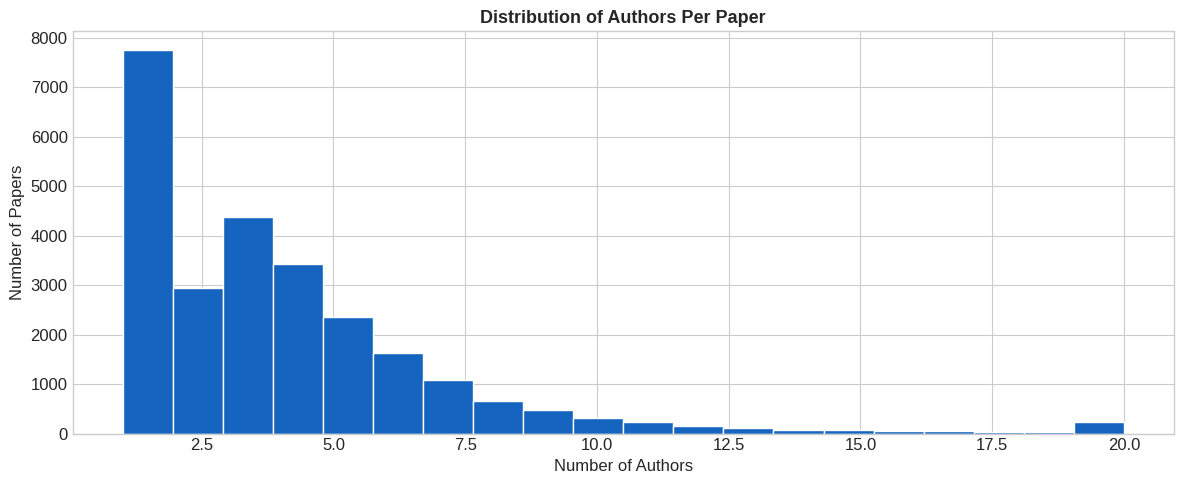

✅ Collaboration analysis saved


In [90]:
# ── 9B: Collaboration Patterns ───────────────────────────────────
collaboration_stats = df.groupby('year')['n_authors'].agg(['mean', 'median', 'max']).reset_index()
collaboration_stats = collaboration_stats[collaboration_stats['year'] >= 2000]

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=collaboration_stats['year'],
    y=collaboration_stats['mean'],
    mode='lines+markers',
    name='Mean Authors/Paper',
    line=dict(color='#1976D2', width=2)
))
fig.add_trace(go.Scatter(
    x=collaboration_stats['year'],
    y=collaboration_stats['median'],
    mode='lines+markers',
    name='Median Authors/Paper',
    line=dict(color='#4CAF50', width=2, dash='dash')
))
fig.update_layout(
    title='Average Number of Authors Per Paper Over Time',
    xaxis_title='Year',
    yaxis_title='Authors per Paper',
    height=400
)
fig.show()
fig.write_html('collaboration_trends.html')

# Distribution of paper sizes
plt.figure(figsize=(12, 5))
df['n_authors'].clip(upper=20).hist(bins=20, color='#1565C0', edgecolor='white')
plt.title('Distribution of Authors Per Paper', fontsize=13, fontweight='bold')
plt.xlabel('Number of Authors')
plt.ylabel('Number of Papers')
plt.tight_layout()
plt.savefig('author_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Collaboration analysis saved')

In [91]:
# ── 9C: Journal / Venue Analysis ────────────────────────────────
if 'journal_ref' in df.columns:
    journal_counts = (
        df['journal_ref']
        .dropna()
        .str.strip()
        .value_counts()
        .head(20)
    )

    fig = px.bar(
        x=journal_counts.values,
        y=journal_counts.index,
        orientation='h',
        title='Top 20 Journals / Venues',
        labels={'x': 'Papers', 'y': 'Journal'},
        color=journal_counts.values,
        color_continuous_scale='Teal'
    )
    fig.update_layout(height=600, showlegend=False)
    fig.show()
    fig.write_html('top_journals.html')
    print('✅ Journal analysis saved')
else:
    print('⚠️  journal_ref column not found — skipping journal analysis')

✅ Journal analysis saved


## 🔍 STEP 10 — Research Gap Detection

In [92]:
# ── 10A: Gap Analysis via Topic Density Over Time ────────────────
print('Detecting research gaps...')

recent_years = df[df['year'] >= df['year'].max() - 5]
older_years  = df[df['year'].between(df['year'].max() - 15, df['year'].max() - 6)]

recent_topic_dist = recent_years['topic_label'].value_counts(normalize=True)
older_topic_dist  = older_years['topic_label'].value_counts(normalize=True)

gap_df = pd.DataFrame({
    'recent_proportion' : recent_topic_dist,
    'older_proportion'  : older_topic_dist
}).fillna(0)

gap_df['growth_rate'] = (
    (gap_df['recent_proportion'] - gap_df['older_proportion'])
    / (gap_df['older_proportion'] + 1e-6)
) * 100

gap_df = gap_df.sort_values('growth_rate', ascending=False)

fig = go.Figure(go.Bar(
    x=gap_df['growth_rate'],
    y=gap_df.index,
    orientation='h',
    marker_color=[
        '#4CAF50' if x > 0 else '#F44336'
        for x in gap_df['growth_rate']
    ]
))
fig.update_layout(
    title='Topic Growth Rate: Recent (last 5 yrs) vs Previous Decade',
    xaxis_title='Growth Rate (%)',
    yaxis_title='Research Topic',
    height=500
)
fig.show()
fig.write_html('research_gap_growth.html')

print('\n=== Emerging Topics (High Growth) ===')
print(gap_df[gap_df['growth_rate'] > 0].to_string())
print('\n=== Declining Topics (Potential Gaps) ===')
print(gap_df[gap_df['growth_rate'] < 0].to_string())

Detecting research gaps...



=== Emerging Topics (High Growth) ===
                                                                                                                    recent_proportion  older_proportion  growth_rate
topic_label                                                                                                                                                         
learning, model, prediction, based, deep, performance, machine, task, drug, feature, image, framework                        0.321205          0.108987   194.717362
cancer, patient, disease, clinical, treatment, tumor, risk, imaging, diagnosis, study, blood, detection                      0.057909          0.046172    25.418182
network, brain, neural, human, functional, information, neural network, visual, connectivity, task, cognitive, eeg           0.133801          0.120338    11.187474

=== Declining Topics (Potential Gaps) ===
                                                                                             

In [93]:
# ── 10B: Keyword Gap — Low Coverage High-Value Terms ────────────
# Identify keywords that appear very rarely (potential under-explored areas)
keyword_doc_freq = np.array((tfidf_matrix > 0).sum(axis=0)).flatten()
keyword_avg_tfidf = np.array(tfidf_matrix.mean(axis=0)).flatten()

gap_keywords_df = pd.DataFrame({
    'keyword'   : feature_names,
    'doc_freq'  : keyword_doc_freq,
    'avg_tfidf' : keyword_avg_tfidf
})
low_freq_threshold = gap_keywords_df['doc_freq'].quantile(0.25)
high_tfidf_threshold = gap_keywords_df['avg_tfidf'].quantile(0.75)

print("Low freq threshold:", low_freq_threshold)
print("High tfidf threshold:", high_tfidf_threshold)
gap_keywords_df['gap_score'] = (
    gap_keywords_df['avg_tfidf'] /
    gap_keywords_df['doc_freq']
)

research_gaps = gap_keywords_df.sort_values(
    'gap_score',
    ascending=False
)

print(research_gaps.head(30))

research_gaps.head(50).to_csv(
    'potential_research_gaps.csv',
    index=False
)

print("Saved successfully!")

Low freq threshold: 100.0
High tfidf threshold: 0.0015384311715037925
                   keyword  doc_freq  avg_tfidf  gap_score
4846                 valve        24   0.000389   0.000016
2052              graphene        25   0.000404   0.000016
1009                 coral        23   0.000360   0.000016
4972             wolbachia        26   0.000398   0.000015
1114                   ddi        28   0.000417   0.000015
2214                   idp        25   0.000367   0.000015
185                    amp        29   0.000401   0.000014
409                    bee        44   0.000595   0.000014
701                 chiral        43   0.000565   0.000013
3150                  odor        40   0.000524   0.000013
4915            wastewater        32   0.000417   0.000013
567                   bump        31   0.000404   0.000013
4563                   tcr        45   0.000586   0.000013
3949        retrosynthesis        34   0.000442   0.000013
1357                   dog        52   0.0006

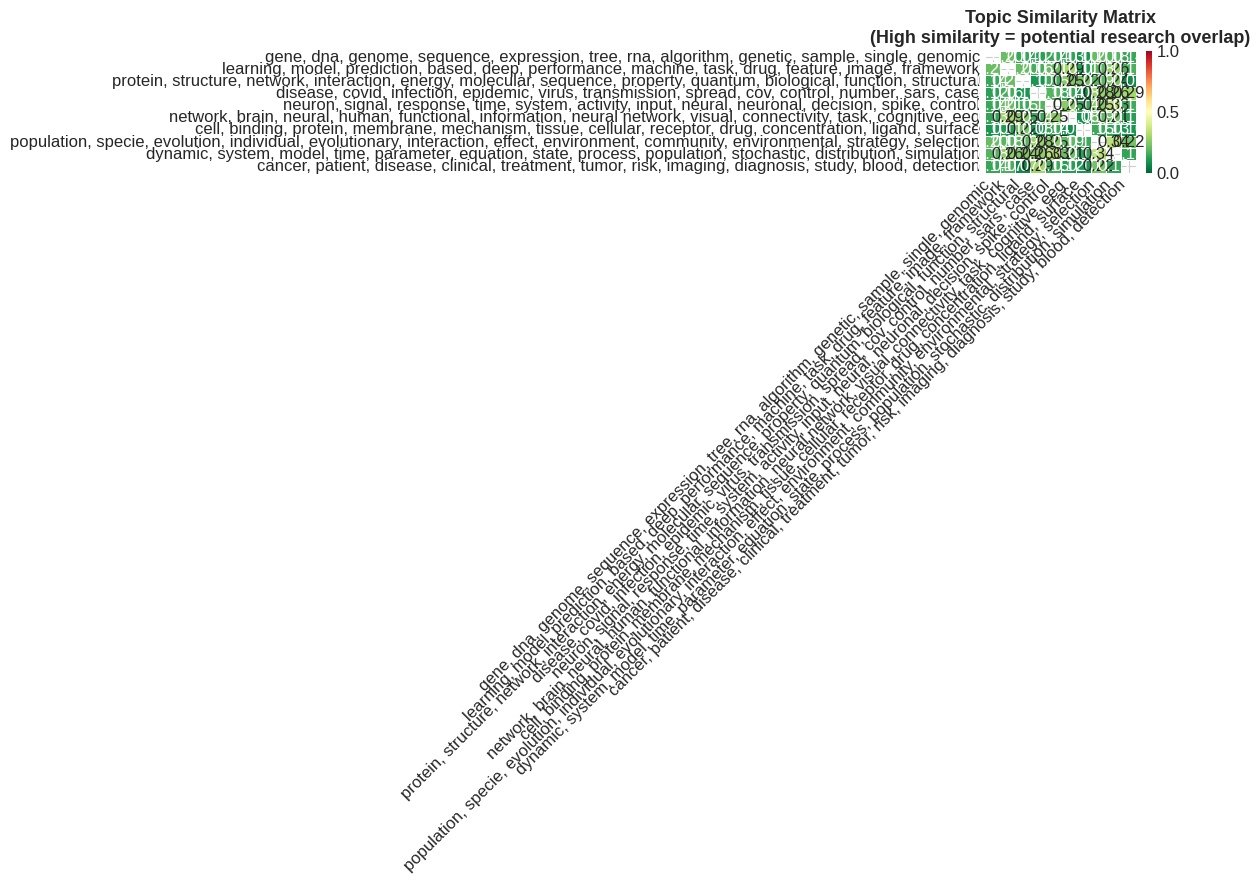

✅ Topic similarity matrix saved


In [94]:
# ── 10C: Topic Similarity Matrix ────────────────────────────────
# How different are the topics from each other? (lower similarity = more distinct)
topic_keyword_matrix = lda_model.components_ / lda_model.components_.sum(axis=1, keepdims=True)
topic_sim = cosine_similarity(topic_keyword_matrix)

labels = [TOPIC_LABELS[i] for i in range(N_TOPICS)]
topic_sim_df = pd.DataFrame(topic_sim, index=labels, columns=labels)

plt.figure(figsize=(12, 9))
mask = np.eye(N_TOPICS, dtype=bool)
sns.heatmap(
    topic_sim_df,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    mask=mask,
    vmin=0, vmax=1,
    linewidths=0.5
)
plt.title('Topic Similarity Matrix\n(High similarity = potential research overlap)',
          fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('topic_similarity_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Topic similarity matrix saved')

## 🌐 STEP 11 — Emerging Domain Detection

Computing keyword velocity over time...


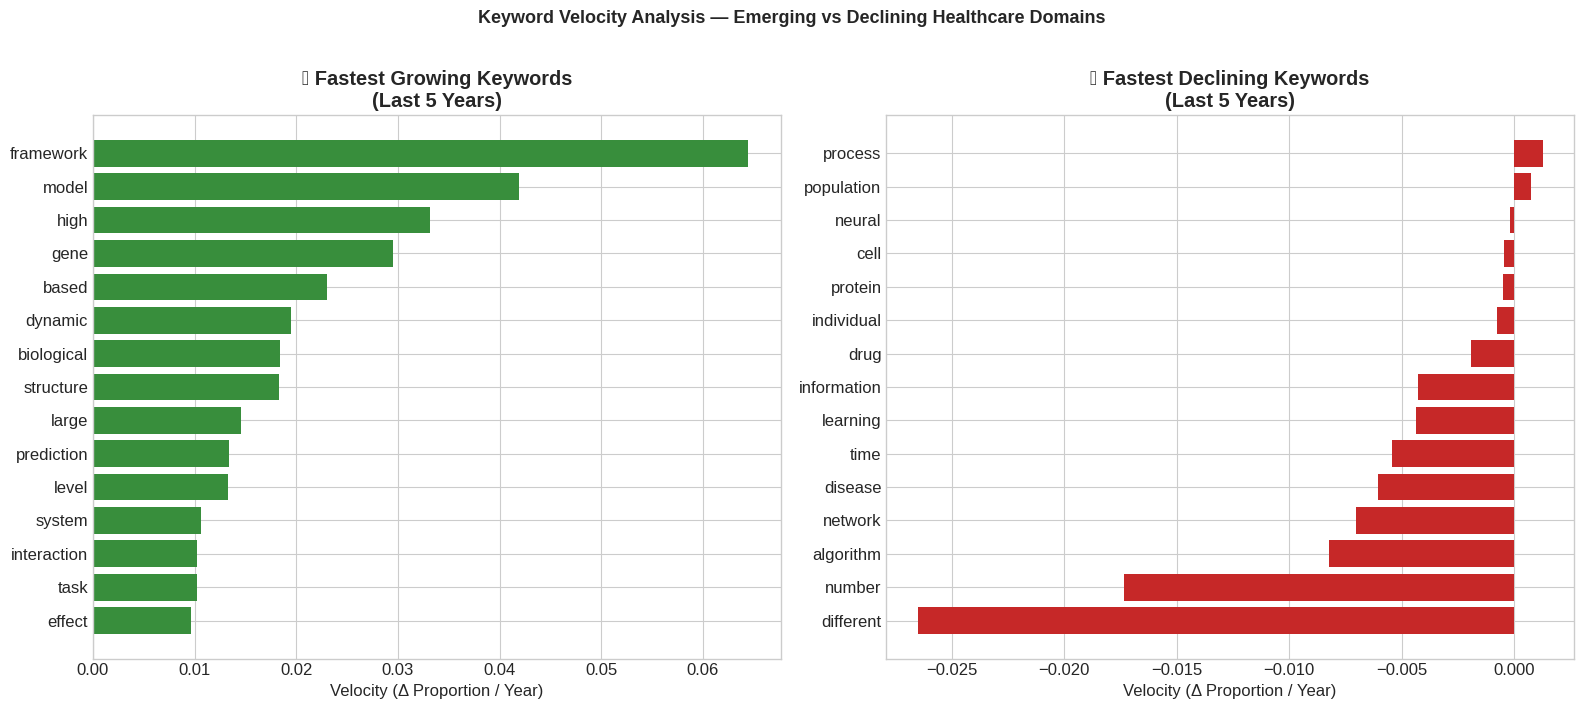

✅ Keyword velocity analysis saved


In [95]:
# ── 11A: Keyword Velocity (Rate of Change) ───────────────────────
print('Computing keyword velocity over time...')

ANALYSIS_KEYWORDS = list(top_tfidf_keywords.head(40).index)

kw_year_counts = defaultdict(lambda: defaultdict(int))

for _, row in df.iterrows():
    year = row['year']
    if pd.isna(year) or year < 2000:
        continue
    text = row['combined_text']
    for kw in ANALYSIS_KEYWORDS:
        if kw in text:
            kw_year_counts[kw][int(year)] += 1

kw_year_df = pd.DataFrame(kw_year_counts).fillna(0)
kw_year_df = kw_year_df.sort_index()

# Normalise by total papers per year
papers_per_year = df[df['year'] >= 2000].groupby('year').size()
kw_year_norm    = kw_year_df.div(papers_per_year, axis=0).fillna(0)

# Compute velocity: slope of last 5 years
recent_window = kw_year_norm.loc[kw_year_norm.index >= kw_year_norm.index.max() - 4]
velocity = {}
for kw in ANALYSIS_KEYWORDS:
    if kw in recent_window.columns:
        y = recent_window[kw].values
        x = np.arange(len(y))
        if len(y) > 1 and y.std() > 0:
            slope = np.polyfit(x, y, 1)[0]
            velocity[kw] = slope

velocity_df = pd.Series(velocity).sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Rising
top_rising = velocity_df.head(15)
ax1.barh(top_rising.index[::-1], top_rising.values[::-1], color='#388E3C')
ax1.set_title('🚀 Fastest Growing Keywords\n(Last 5 Years)', fontweight='bold')
ax1.set_xlabel('Velocity (Δ Proportion / Year)')

# Declining
top_declining = velocity_df.tail(15)
ax2.barh(top_declining.index[::-1], top_declining.values[::-1], color='#C62828')
ax2.set_title('📉 Fastest Declining Keywords\n(Last 5 Years)', fontweight='bold')
ax2.set_xlabel('Velocity (Δ Proportion / Year)')

plt.suptitle('Keyword Velocity Analysis — Emerging vs Declining Healthcare Domains',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('keyword_velocity.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Keyword velocity analysis saved')

In [96]:
# ── 11B: Bubble Chart — Topic Size vs Growth ────────────────────
topic_summary = df.groupby('topic_label').agg(
    total_papers=('title', 'count'),
    avg_year=('year', 'mean'),
    recent_papers=('year', lambda x: (x >= x.max() - 3).sum())
).reset_index()

topic_summary['growth_pct'] = (
    topic_summary['recent_papers'] / topic_summary['total_papers'] * 100
)

fig = px.scatter(
    topic_summary,
    x='avg_year',
    y='growth_pct',
    size='total_papers',
    color='topic_label',
    text='topic_label',
    title='Topic Landscape — Size vs Recency vs Growth',
    labels={
        'avg_year'    : 'Average Publication Year',
        'growth_pct'  : 'Recent Paper Proportion (%)',
        'total_papers': 'Total Papers'
    },
    size_max=60
)
fig.update_traces(textposition='top center', textfont_size=9)
fig.update_layout(height=600, showlegend=False)
fig.show()
fig.write_html('topic_bubble_chart.html')
print('✅ Bubble chart saved')

✅ Bubble chart saved


## 📄 STEP 12 — Abstract Similarity & Paper Clustering

In [97]:
# ── 12A: UMAP 2D Projection of Papers ───────────────────────────
from umap import UMAP

print('Computing UMAP 2D projection...')

UMAP_SAMPLE = min(26000, len(df))
umap_df = df.sample(UMAP_SAMPLE, random_state=42).reset_index(drop=True)

# TF-IDF sub-matrix for this sample
umap_tfidf = tfidf.transform(umap_df['combined_text'])
umap_tfidf_norm = normalize(umap_tfidf)

reducer = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(umap_tfidf_norm.toarray())

umap_df['umap_x'] = embedding[:, 0]
umap_df['umap_y'] = embedding[:, 1]

fig = px.scatter(
    umap_df,
    x='umap_x',
    y='umap_y',
    color='topic_label',
    hover_data=['title', 'year'],
    title=f'UMAP Projection of {UMAP_SAMPLE} Healthcare Papers (coloured by LDA Topic)',
    labels={'umap_x': 'UMAP-1', 'umap_y': 'UMAP-2', 'topic_label': 'Topic'},
    opacity=0.6
)
fig.update_traces(marker=dict(size=4))
fig.update_layout(height=650)
fig.show()
fig.write_html('umap_paper_clusters.html')
print('✅ UMAP projection saved')

Output hidden; open in https://colab.research.google.com to view.

## 📊 STEP 13 — Category Distribution & Cross-Category Analysis

In [98]:
# ── 13A: ArXiv Category Distribution ────────────────────────────
if 'categories' in df.columns:
    # Split multi-category entries
    all_cats = []
    for cats in df['categories'].dropna():
        all_cats.extend(str(cats).split())

    cat_counts = Counter(all_cats)
    cat_df = pd.DataFrame(cat_counts.most_common(20),
                          columns=['category', 'count'])

    fig = px.pie(
        cat_df.head(12),
        values='count',
        names='category',
        title='ArXiv Category Distribution — Healthcare Papers',
        hole=0.4
    )
    fig.update_layout(height=500)
    fig.show()
    fig.write_html('category_distribution.html')

    # Category trend over time
    top_5_cats = [c[0] for c in cat_counts.most_common(5)]
    cat_year_data = []
    for _, row in df.iterrows():
        if pd.isna(row.get('categories')) or pd.isna(row.get('year')):
            continue
        for cat in str(row['categories']).split():
            if cat in top_5_cats:
                cat_year_data.append({'category': cat, 'year': row['year']})

    cat_year_df = pd.DataFrame(cat_year_data)
    cat_year_counts = cat_year_df.groupby(['year', 'category']).size().reset_index(name='count')
    cat_year_counts = cat_year_counts[cat_year_counts['year'] >= 2015]

    fig2 = px.line(
        cat_year_counts,
        x='year',
        y='count',
        color='category',
        title='Top ArXiv Categories — Publication Trends',
        markers=True
    )
    fig2.show()
    fig2.write_html('category_trends.html')
    print('✅ Category analysis saved')

✅ Category analysis saved


## 📋 STEP 14 — Export Enriched Dataset & Summary Statistics

In [ ]:
# ── 14A: Save Enriched Dataset ───────────────────────────────────
output_cols = [
    'id', 'title', 'abstract', 'year',
    'categories', 'authors',
    'n_authors', 'dominant_topic_lda',
    'topic_label', 'topic_confidence',
    'abstract_clean'
]
output_cols = [c for c in output_cols if c in df.columns]

enriched_df = df[output_cols].copy()
enriched_df.to_csv('healthcare_papers_enriched.csv', index=False)
print(f'✅ Enriched dataset saved: {len(enriched_df):,} rows')

# Save keyword tables
pd.DataFrame({'keyword': top_tfidf_keywords.head(100).index,
              'tfidf_score': top_tfidf_keywords.head(100).values}).to_csv('top_keywords_tfidf.csv', index=False)
pd.DataFrame({'keyword': top_yake.head(100).index,
              'frequency': top_yake.head(100).values}).to_csv('top_keywords_yake.csv', index=False)
pd.DataFrame({'keyword': top_keybert.head(100).index,
              'frequency': top_keybert.head(100).values}).to_csv('top_keywords_keybert.csv', index=False)

# Save LDA topic words
topic_words_rows = []
for topic_id, words in lda_topics.items():
    for rank, word in enumerate(words):
        topic_words_rows.append({'topic': topic_id,
                                  'label': TOPIC_LABELS[int(topic_id.split()[-1])],
                                  'rank': rank + 1,
                                  'word': word})
pd.DataFrame(topic_words_rows).to_csv('lda_topic_words.csv', index=False)

print('✅ All keyword tables saved')

In [ ]:
# ── 14B: Summary Statistics Dashboard ───────────────────────────
print('\n' + '='*60)
print('   AI RESEARCH PAPER LITERATURE ANALYZER — FINAL SUMMARY')
print('   Healthcare Domain (ArXiv q-bio)')
print('='*60)

print(f'\n📊 DATASET')
print(f'   Total healthcare papers analysed : {len(df):>8,}')
print(f'   Year range                       : {int(df["year"].min())} – {int(df["year"].max())}')
print(f'   Unique authors                   : {len(author_counts):>8,}')
print(f'   Avg authors per paper            : {df["n_authors"].mean():>8.1f}')

print(f'\n🔑 KEYWORDS')
print(f'   TF-IDF keywords extracted        : {len(tfidf_scores):>8,}')
print(f'   YAKE keywords extracted          : {len(yake_freq):>8,}')
print(f'   KeyBERT keywords extracted       : {len(keybert_freq):>8,}')
print(f'   Top TF-IDF keyword               : {top_tfidf_keywords.index[0]}')

print(f'\n🗂️  TOPICS (LDA, {N_TOPICS} topics)')
for lbl, cnt in df['topic_label'].value_counts().items():
    pct = cnt / len(df) * 100
    print(f'   {lbl:<42} {cnt:>5,}  ({pct:4.1f}%)')

print(f'\n🌐 NETWORK')
print(f'   Co-occurrence nodes              : {G.number_of_nodes():>8,}')
print(f'   Co-occurrence edges              : {G.number_of_edges():>8,}')
top_node = max(degree_centrality, key=degree_centrality.get)
print(f'   Most central keyword             : {top_node}')

print(f'\n🚀 EMERGING DOMAINS')
for kw, vel in velocity_df.head(5).items():
    print(f'   {kw:<40} velocity: {vel:+.4f}')

print(f'\n📁 OUTPUT FILES')
output_files = [
    'healthcare_papers_enriched.csv',
    'top_keywords_tfidf.csv',
    'top_keywords_yake.csv',
    'top_keywords_keybert.csv',
    'lda_topic_words.csv',
    'keyword_network_centrality.csv',
    'potential_research_gaps.csv',
    'keywords_comparison.png',
    'wordcloud_healthcare.png',
    'topic_heatmap.png',
    'keyword_cooccurrence_network.png',
    'keyword_velocity.png',
    'umap_paper_clusters.html',
    'topic_bubble_chart.html',
    'research_gap_growth.html'
]
for f in output_files:
    exists = '✅' if os.path.exists(f) else '❌'
    print(f'   {exists} {f}')

print('\n' + '='*60)
print('   Pipeline complete!')
print('='*60)

## ⬇️ STEP 16 — Download All Results

In [ ]:
# Zip and download everything
import zipfile

zip_name = 'literature_analyzer_results.zip'
all_files = [
    'healthcare_papers_enriched.csv',
    'top_keywords_tfidf.csv',
    'top_keywords_yake.csv',
    'top_keywords_keybert.csv',
    'lda_topic_words.csv',
    'keyword_network_centrality.csv',
    'potential_research_gaps.csv',
    'keywords_comparison.png',
    'wordcloud_healthcare.png',
    'topic_heatmap.png',
    'keyword_cooccurrence_network.png',
    'keyword_velocity.png',
    'topic_similarity_matrix.png',
    'author_distribution.png',
    'ner_entities.png',
    'umap_paper_clusters.html',
    'topic_bubble_chart.html',
    'research_gap_growth.html',
    'lda_topic_distribution.html',
    'topic_trends_over_time.html',
    'publication_trends.html',
    'bertopic_barchart.html',
    'top_authors.html',
    'collaboration_trends.html'
]

with zipfile.ZipFile(zip_name, 'w') as zf:
    for f in all_files:
        if os.path.exists(f):
            zf.write(f)

print(f'✅ Zip created: {zip_name}')

# Download to local machine
from google.colab import files
files.download(zip_name)
print('✅ Download started!')

In [101]:
# Zip and download everything
import zipfile

zip_name = 'literature_analyzer_results.zip'
all_files = [
    'category_trends.html',
    'category_distribution.html'
]

with zipfile.ZipFile(zip_name, 'w') as zf:
    for f in all_files:
        if os.path.exists(f):
            zf.write(f)

print(f'✅ Zip created: {zip_name}')

# Download to local machine
from google.colab import files
files.download(zip_name)
print('✅ Download started!')

✅ Zip created: literature_analyzer_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started!
